In [14]:
import xarray as xr
import pandas as pd
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import os
os.environ['ESMFMKFILE'] = 'C:/Users/eving/AppData/Local/miniconda3/envs/evalprecextremes/Library/lib/esmf.mk'
import xesmf as xe
import numpy as np
np.float_ = np.float64
from metpy.units import units
import matplotlib.colors as mcolors
from clisops.core import subset
from metpy.plots import ctables
import matplotlib.ticker as ticker
import cmaps
import geopandas as gpd
import seaborn as sns
from shapely.geometry import Point, Polygon
import rioxarray
from math import nan
from scipy import stats
import statsmodels.api as sm
from collections import OrderedDict
import sys
import matplotlib.colors as colors

# Original Projection
projorig_name  = "PlateCarree"
projorig_dict  = dict()
projorig       = ccrs.__dict__[projorig_name].__call__(**projorig_dict)

# Input data
# EURO-CORDEX RCMs
RCMs = OrderedDict() 
RCMs['CNRM-ALADIN64E1'] = {'projplot' : 'LambertConformal',
                           'projplot_dict' : dict(central_longitude=10.5, central_latitude=49.5, standard_parallels=(33,45), false_easting = 2925000., false_northing = 2925000.)}
RCMs['HCLIM43-ALADIN'] = {'projplot' : 'LambertConformal',
                          'projplot_dict' : dict(central_longitude=10.5, central_latitude=49.5, standard_parallels=(33,45), false_easting = 2925000., false_northing = 2925000.)}
RCMs['ALARO1-SFX'] = {'projplot' : 'LambertConformal',
                      'projplot_dict' : dict(central_longitude=9.9, central_latitude=49.0, standard_parallels=(33,45), false_easting = 3012.5, false_northing = 3012.5)}
RCMs['RACMO23E']   = {'projplot' : 'RotatedPole',
                      'projplot_dict' : dict(pole_longitude=-162, pole_latitude=39.25, central_rotated_longitude=-162)}
RCMs['ICON-CLM-202407-1-1'] = {'projplot' : 'RotatedPole',
                               'projplot_dict' : dict(pole_longitude=-162, pole_latitude=39.25, central_rotated_longitude=-162)}
RCMs['CCLM6-0-1'] = {'projplot' : 'RotatedPole',
                     'projplot_dict' : dict(pole_longitude=-162, pole_latitude=39.25, central_rotated_longitude=-162)}
RCMs['RegCM5-0'] = {'projplot' : 'RotatedPole',
                    'projplot_dict' : dict(pole_longitude=198, pole_latitude=39.25, central_rotated_longitude=-162)}
RCMs['REMO2020-2-2'] = {'projplot' : 'RotatedPole',
                        'projplot_dict' : dict(pole_longitude=-162, pole_latitude=39.25, central_rotated_longitude=-162)}
RCMs['WRF451Q'] = {'projplot' : 'RotatedPole',
                   'projplot_dict' : dict(pole_longitude=-162, pole_latitude=39.25, central_rotated_longitude=-162)}

# Graphic projection
projplot       = "LambertConformal"
projplot_dict  = dict(central_longitude=10.5, central_latitude=49.5, standard_parallels=(33,45))
projplot       = ccrs.__dict__[projplot].__call__(**projplot_dict)

folder_obs = 'D:/EUROCORDEX_extremes/DATA/OBS/'
folder_model = 'D:/EUROCORDEX_extremes/DATA/SIM/'

# reference file for the regridding
fMod = 'ERA5_WRF451Q1980-2020_SON_all_24h_perc.nc'
dsMod = xr.load_dataset(folder_model+fMod, engine="netcdf4")
rlat_424_412 = dsMod.rlat.values
rlon_424_412 = dsMod.rlon.values

# list models and obs
name_models = ['ERA5_ALARO1-SFX','ERA5_CCLM6-0-1','ERA5_CNRM-ALADIN64E1',
            'ERA5_HCLIM43-ALADIN','ERA5_ICON-CLM-202407-1-1','ERA5_RACMO23E',
            'ERA5_RegCM5-0','ERA5_REMO2020-2-2','ERA5_WRF451Q']
label_models = ['ALARO1-SFX','CCLM6-0-1','ALADIN64E1',
            'HCLIM43','ICON-CLM','RACMO23E',
            'RegCM5-0','REMO2020','WRF451Q']
name_obs = 'OBS_EURADCLIM_011EUi_2013-2022'

gdf = gpd.read_file("regions.geojson")

def quatromatrix(left, bottom, right, top, ax=None, triplotkw={},tripcolorkw={}):
    if not ax: ax=plt.gca()
    n = left.shape[0]; m=left.shape[1]

    a = np.array([[0,0],[0,1],[.5,.5],[1,0],[1,1]])
    tr = np.array([[0,1,2], [0,2,3],[2,3,4],[1,2,4]])

    A = np.zeros((n*m*5,2))
    Tr = np.zeros((n*m*4,3))

    for i in range(n):
        for j in range(m):
            k = i*m+j
            A[k*5:(k+1)*5,:] = np.c_[a[:,0]+j, a[:,1]+i]
            Tr[k*4:(k+1)*4,:] = tr + k*5

    C = np.c_[ left.flatten(), bottom.flatten(), 
              right.flatten(), top.flatten()   ].flatten()

    triplot = ax.triplot(A[:,0], A[:,1], Tr, **triplotkw)
    tripcolor = ax.tripcolor(A[:,0], A[:,1], Tr, facecolors=C, **tripcolorkw)
    return tripcolor

In [17]:

# try at an hourly scale
agg = '1'

quantile = 'perc_99.00'

#======================================================================
# STEP 1: create and save a data.frame with all the data for the boxplot
#======================================================================
# generate a fake df
# 1. Initialize an empty list
df_list = []

# 2. Run the loop to collect small dataframes
for ir, season in enumerate(['JJA','SON','DJF','MAM']):
    print("=============================================================")
    print(season)        
    print("=============================================================")

    # load mask
    mask = np.load(f'D:/EUROCORDEX_extremes/DATA/OBS/mask_eurad_{season}_era.npy')

    fObs = f'{name_obs}_{season}_all_{agg}h_perc.nc'
    dsObs = xr.load_dataset(folder_obs+fObs, engine="netcdf4")
    dsObs_cor = dsObs.cf.add_bounds(["lon","lat"])
    
    for model in name_models:
        # corresponding label for the model
        model_label = label_models[name_models.index(model)]
        
        # reference file for the regridding
        fMod = f'{model}1980-2020_{season}_all_{agg}h_perc.nc'
        print(fMod)
        
        # aladin simulation to be regridded
        dsMod = xr.load_dataset(folder_model+fMod, engine="netcdf4")

        if model == 'ERA5_RegCM5-0':
            dsMod = dsMod.assign_coords(rlat=rlat_424_412, rlon=rlon_424_412)

        dsMod = dsMod.cf.add_bounds(["lon","lat"])

        # regrid obs
        regridder = xe.Regridder(
            dsMod, dsObs_cor, "conservative", unmapped_to_nan=True, ignore_degenerate=True
        )
        dsMod_regrid = regridder(dsMod, keep_attrs=True)

        ZOBS = dsObs_cor[quantile]
        ZMOD = dsMod_regrid[quantile]

        ZOBS = np.where(mask, np.nan, ZOBS) # Set values outside the range to NaN
        ZMOD = np.where(mask, np.nan, ZMOD) # Set values outside the range to NaN
        Z = (ZMOD / ZOBS - 1) * 100

        Z2CLIP = dsObs_cor[quantile].copy(deep=True)
        Z2CLIP.values = Z
        Z2CLIP.rio.write_crs("EPSG:4326", inplace=True)

        # reproject the GeoDataFrame to match the CRS of the raster data
        gdf_proj = gdf.to_crs(Z2CLIP.rio.crs)

        for ic, region in gdf.iterrows():
    
            # prepare data for boxplot
            Zclip = Z2CLIP.rio.clip([region['geometry']], crs=gdf_proj.crs)
            zvec = Zclip.values.flatten()
            zvec = zvec[~np.isnan(zvec)]
            nzvec = len(zvec)

            # Simulated dataframe generation
            small_df = pd.DataFrame({"season": [season]*nzvec, 
                                    "region": [region['names']]*nzvec,
                                    "model": [model_label]*nzvec, 
                                    "value": zvec})
            df_list.append(small_df)


# 3. Concatenate everything once after the loop
df_plot = pd.concat(df_list, ignore_index=True)
df_plot.to_csv(f'D:/EUROCORDEX_extremes/FIGURES/DIFF_BOXPLOT_EURAD/boxplot_{agg}h_reldiff_{quantile}.csv', index=False)


JJA
ERA5_ALARO1-SFX1980-2020_JJA_all_1h_perc.nc


c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')


ERA5_CCLM6-0-11980-2020_JJA_all_1h_perc.nc


c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


ERA5_CNRM-ALADIN64E11980-2020_JJA_all_1h_perc.nc


...

c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')


ERA5_REMO2020-2-21980-2020_MAM_all_1h_perc.nc


c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


ERA5_WRF451Q1980-2020_MAM_all_1h_perc.nc


c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\xesmf\backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')


c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


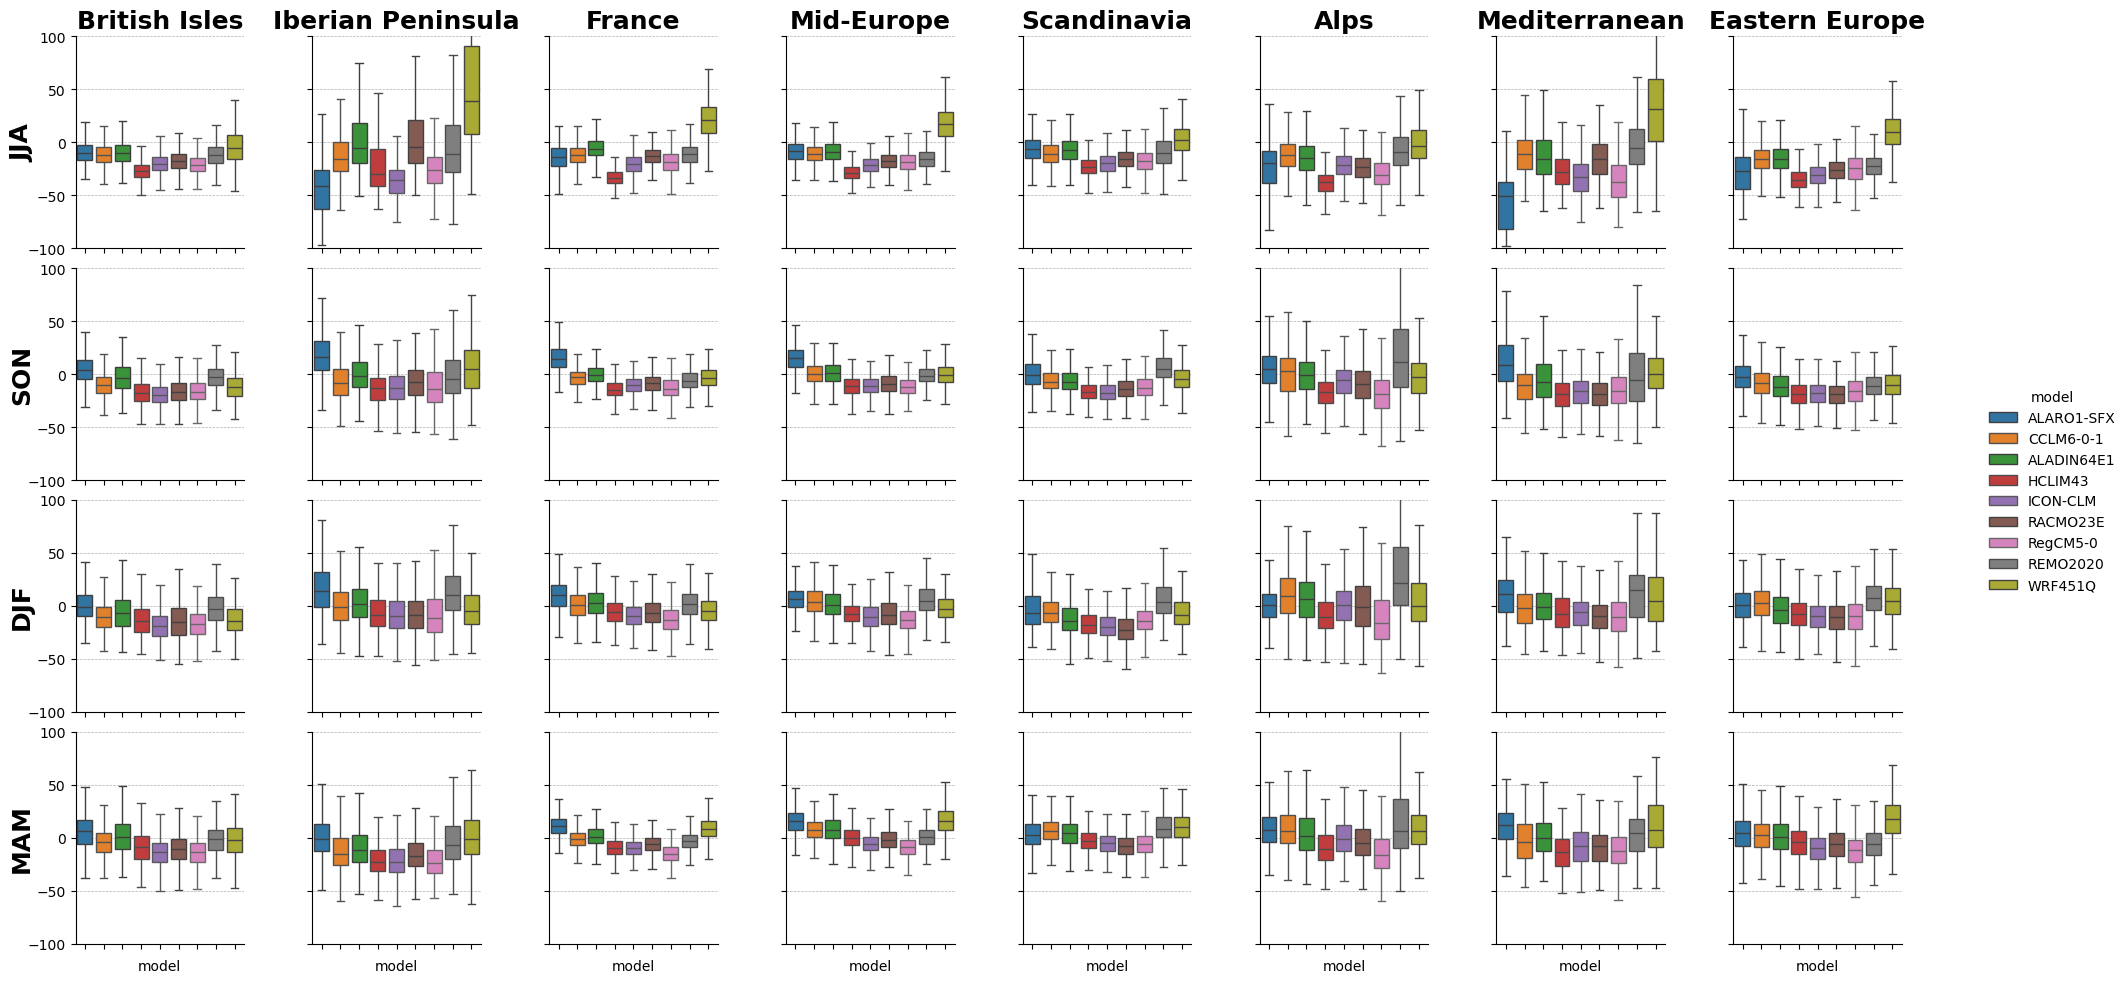

In [18]:
#======================================================================
# STEP 2: FIGURE BOXPLOT
#======================================================================

# read csv file
df_plot = pd.read_csv(f'D:/EUROCORDEX_extremes/FIGURES/DIFF_BOXPLOT_EURAD/boxplot_{agg}h_reldiff_{quantile}.csv')

g = sns.FacetGrid(df_plot, row="season",col="region", hue="model",margin_titles=True, height=2.5)
g.map(sns.boxplot, "model", "value", showfliers=False)
g.add_legend()
g.set(ylim=(-100, 100))

# Returns the column name string (e.g., "time")
region_names = g.col_names

# Changes title from "your_column = value" to just "value"
g.set_titles(row_template="", col_template="")

for ax,m in zip(g.axes[0,:],region_names):
    ax.set_title(m, fontweight='bold', fontsize=18)
for ax,l in zip(g.axes[:,0],['JJA','SON','DJF','MAM']):
    ax.set_ylabel(l, fontweight='bold', fontsize=18, rotation=90, ha='center', va='center')

# Remove x-axis labels from all facets
for ax in g.axes.flatten():
    ax.grid(True, which='both', axis='y', linestyle='--', linewidth=0.5)
    ax.set_xticklabels("")

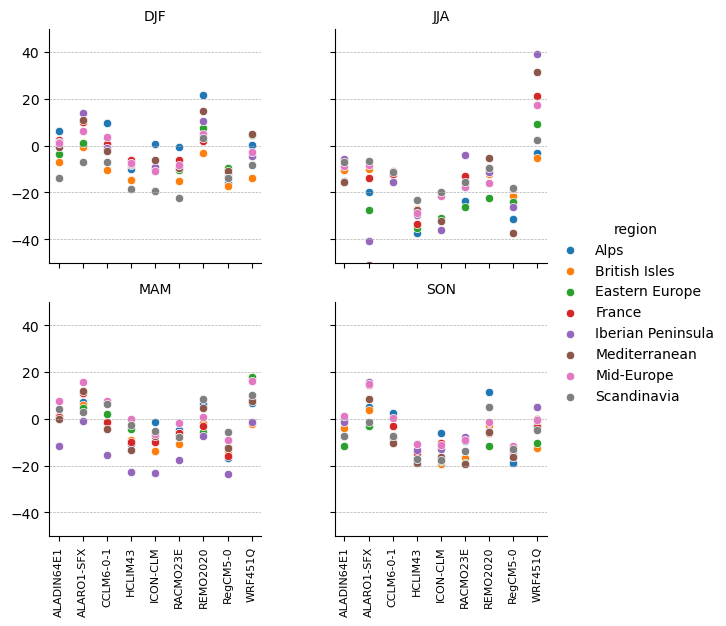

In [19]:
#======================================================================
# STEP 3: FIGURE POINTS MEDIAN
#======================================================================

# read csv file
df_plot = pd.read_csv(f'D:/EUROCORDEX_extremes/FIGURES/DIFF_BOXPLOT_EURAD/boxplot_{agg}h_reldiff_{quantile}.csv')

df_median = df_plot.groupby(['season', 'region', 'model'])["value"].median().reset_index()

g = sns.FacetGrid(df_median, col="season",col_wrap=2, hue="region",margin_titles=True, height=3)
g.map_dataframe(sns.scatterplot, x="model", y="value")
g.add_legend()
g.set(ylim=(-50, 50))

# Changes title from "your_column = value" to just "value"
g.set_titles(row_template="", col_template="{col_name}")

g.set_xlabels(label="")
g.set_ylabels(label="")
g.tick_params(axis='x', rotation=90, labelsize=8)


# Remove x-axis labels from all facets
for ax in g.axes.flatten():
    ax.grid(True, which='both', axis='y', linestyle='--', linewidth=0.5)


(np.float64(-0.05), np.float64(1.05), np.float64(-0.05), np.float64(1.05))

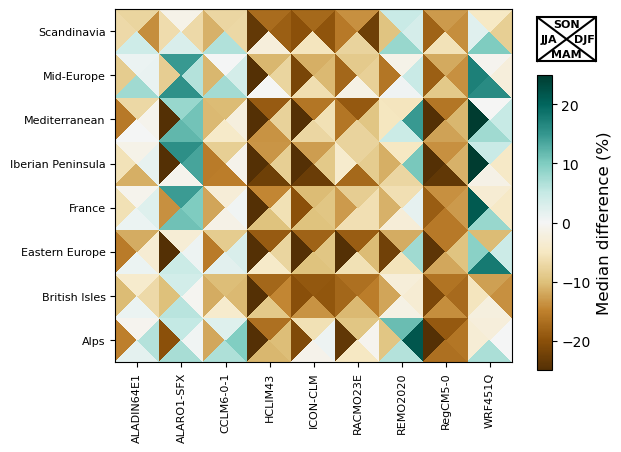

In [21]:
#======================================================================
# STEP 4: FIGURE HEATMAP MEDIAN
#======================================================================

# format df_median to be used in the quatromatrix function
vecregion = np.unique(df_median["region"])
vecmodel = np.unique(df_median["model"])

dict_median = {}
for season in ['JJA','SON','DJF','MAM']:
    dict_median[season] = np.zeros((len(vecregion), len(vecmodel)))
    for ir, region in enumerate(vecregion):
        for im, model in enumerate(vecmodel):
            median_value = df_median[(df_median['season'] == season) & 
                                    (df_median['region'] == region) & 
                                    (df_median['model'] == model)]['value'].values
            if len(median_value) > 0:
                dict_median[season][ir, im] = median_value[0]
            else:
                dict_median[season][ir, im] = np.nan

fig, ax = plt.subplots()

p = quatromatrix(dict_median['JJA'], dict_median['MAM'], dict_median['DJF'], dict_median['SON'], ax=ax,
            tripcolorkw={"cmap": "BrBG", "vmin":-25, "vmax":25}) 

ax.margins(0)
ax.set_aspect("equal")

# change the ticks and labels
ax.set_xticks(np.arange(len(vecmodel))+0.5)
ax.set_xticklabels(vecmodel, rotation=90, fontsize=8)
ax.set_yticks(np.arange(len(vecregion))+0.5)
ax.set_yticklabels(vecregion, fontsize=8)

# add colorbar
cbar = fig.colorbar(p, ax=ax, aspect=20, orientation="vertical", shrink=0.8, anchor=(0.0, 0.0))
cbar.set_label('Median difference (%)', fontsize=12)

# Coordinates [left, bottom, width, height] as fractions of the figure (0 to 1)
ax2 = fig.add_axes([0.78, 0.75, 0.1, 0.1])

# 2. Cross the square with diagonal lines to form 4 triangles
ax2.plot([0, 1], [0, 1], color='black', lw=1.5) # Diagonal from bottom-left to top-right
ax2.plot([0, 1], [1, 0], color='black', lw=1.5) # Diagonal from top-left to bottom-right

# add rectangle to the axes
rect = plt.Rectangle((0, 0), 1, 1, fill=False, edgecolor='black', lw=1.5)
ax2.add_patch(rect)

# 3. Place seasonal text in the perfect center coordinates of each triangle quadrant
ax2.text(0.5, 0.85, 'SON', fontsize=8, ha='center', va='center', weight='bold')
ax2.text(0.5, 0.15, 'MAM', fontsize=8, ha='center', va='center', weight='bold')
ax2.text(0.2, 0.5, 'JJA', fontsize=8, ha='center', va='center', weight='bold')
ax2.text(0.8, 0.5, 'DJF', fontsize=8, ha='center', va='center', weight='bold')

# Remove outer tick marks and coordinate grid axes for a clean graphic
ax2.set_xlim(-0.05, 1.05)
ax2.set_ylim(-0.05, 1.05)
ax2.axis('off')

(np.float64(-0.05), np.float64(1.05), np.float64(-0.05), np.float64(1.05))

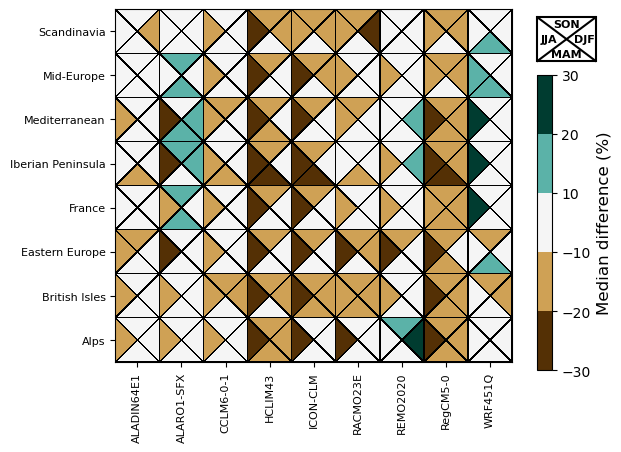

In [22]:
#======================================================================
# STEP 5: FIGURE HEATMAP MEDIAN, OTHER COLOR SCALE
#======================================================================

# 1. Define your custom data bin edges/boundaries
bounds = [-30,-20,-10,10,20,30]

# 2. Track how many intervals you created (4 intervals)
n_colors = len(bounds) - 1

# 3. Fetch a continuous map and create the norm configuration
cmap = plt.colormaps['BrBG'].resampled(n_colors)
norm = colors.BoundaryNorm(boundaries=bounds, ncolors=n_colors)

fig, ax=plt.subplots()

p = quatromatrix(dict_median['JJA'], dict_median['MAM'], dict_median['DJF'], dict_median['SON'], ax=ax,
            triplotkw={"color":"k", "lw":1},
            tripcolorkw={"cmap": cmap, "norm": norm, "ec": "k"}) 

ax.margins(0)
ax.set_aspect("equal")

# change the ticks and labels
ax.set_xticks(np.arange(len(vecmodel))+0.5)
ax.set_xticklabels(vecmodel, rotation=90, fontsize=8)
ax.set_yticks(np.arange(len(vecregion))+0.5)
ax.set_yticklabels(vecregion, fontsize=8)

# add colorbar
cbar = fig.colorbar(p, ax=ax, aspect=20, orientation="vertical", shrink=0.8, anchor=(0.0, 0.0))
cbar.set_label('Median difference (%)', fontsize=12)

# Coordinates [left, bottom, width, height] as fractions of the figure (0 to 1)
ax2 = fig.add_axes([0.78, 0.75, 0.1, 0.1])

# 2. Cross the square with diagonal lines to form 4 triangles
ax2.plot([0, 1], [0, 1], color='black', lw=1.5) # Diagonal from bottom-left to top-right
ax2.plot([0, 1], [1, 0], color='black', lw=1.5) # Diagonal from top-left to bottom-right

# add rectangle to the axes
rect = plt.Rectangle((0, 0), 1, 1, fill=False, edgecolor='black', lw=1.5)
ax2.add_patch(rect)

# 3. Place seasonal text in the perfect center coordinates of each triangle quadrant
ax2.text(0.5, 0.85, 'SON', fontsize=8, ha='center', va='center', weight='bold')
ax2.text(0.5, 0.15, 'MAM', fontsize=8, ha='center', va='center', weight='bold')
ax2.text(0.2, 0.5, 'JJA', fontsize=8, ha='center', va='center', weight='bold')
ax2.text(0.8, 0.5, 'DJF', fontsize=8, ha='center', va='center', weight='bold')

# Remove outer tick marks and coordinate grid axes for a clean graphic
ax2.set_xlim(-0.05, 1.05)
ax2.set_ylim(-0.05, 1.05)
ax2.axis('off')